In [1]:

# ALWAYS RUN THIS FIRST!
import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path("/rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest")
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))

print(f"✅ Working directory: {os.getcwd()}")

✅ Working directory: /rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest


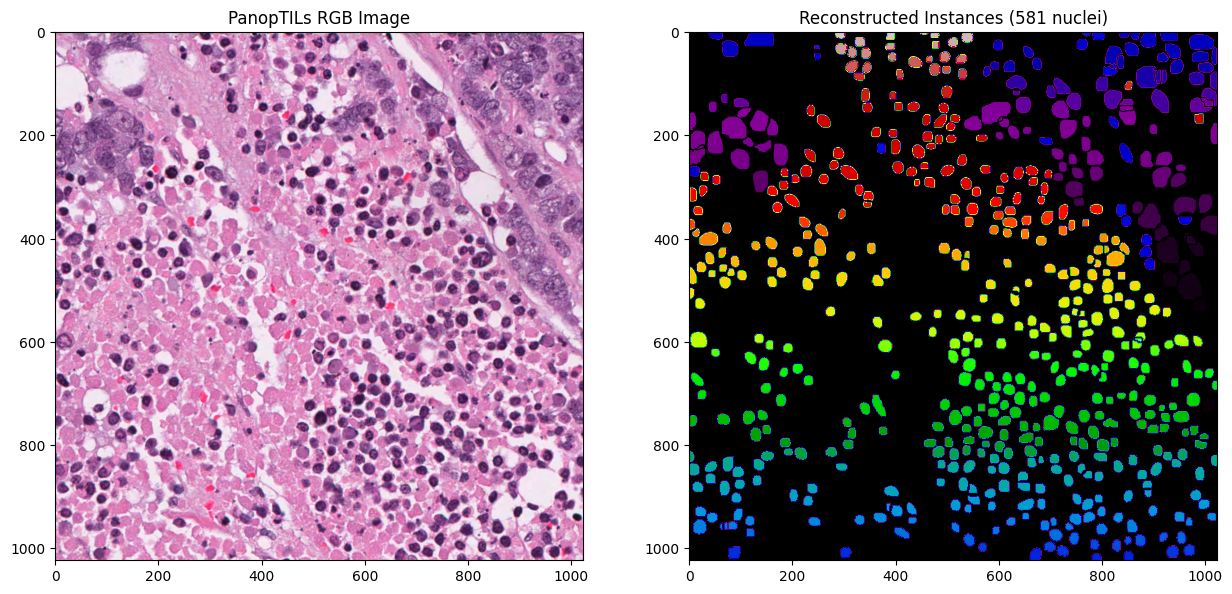

In [4]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# --- CONFIGURATION ---
BASE_PATH = Path("/rsrch9/home/plm/idso_fa1_pathology/TIER1/yasin-vitaminp/public-datasets/PanopTILs/tcga")
IMG_DIR = BASE_PATH / "rgbs"
CSV_DIR = BASE_PATH / "csv"

# Pick a sample from your directory
sample_img_path = next(IMG_DIR.glob("*.png"))
sample_csv_path = CSV_DIR / f"{sample_img_path.stem}.csv"

def load_panoptils_polygons(img_path, csv_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    df = pd.read_csv(csv_path)
    # Focus strictly on polylines for high-fidelity boundaries
    polys = df[df['type'] == 'polyline']
    
    instance_mask = np.zeros((h, w), dtype=np.int32)
    
    for i, (_, row) in enumerate(polys.iterrows(), start=1):
        # Convert comma-separated strings to integer lists
        x = [int(float(c)) for c in str(row['coords_x']).split(',')]
        y = [int(float(c)) for c in str(row['coords_y']).split(',')]
        
        pts = np.array([[[xi, yi] for xi, yi in zip(x, y)]], dtype=np.int32)
        cv2.fillPoly(instance_mask, pts, i)
        
    return img, instance_mask

# Execute and Visualize
image, mask = load_panoptils_polygons(sample_img_path, sample_csv_path)

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("PanopTILs RGB Image")
plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='nipy_spectral')
plt.title(f"Reconstructed Instances ({mask.max()} nuclei)")
plt.show()

In [8]:
import os
import pandas as pd
import numpy as np
import zarr
import cv2
from pathlib import Path
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor

# --- CONFIGURATION ---
BASE_PATH = Path("/rsrch9/home/plm/idso_fa1_pathology/TIER1/yasin-vitaminp/public-datasets/PanopTILs/tcga")
IMG_DIR = BASE_PATH / "rgbs"
CSV_DIR = BASE_PATH / "csv"
OUT_DIR = Path("/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/panoptils/zarr_data")

PATCH_SIZE = 512
NUM_WORKERS = 32

def get_smart_coords(length, crop_size):
    if length <= crop_size: return [0]
    coords = list(range(0, length - crop_size, crop_size))
    coords.append(length - crop_size)
    return sorted(list(set(coords)))

def process_panoptils_slide(args):
    img_path, csv_path, file_name, out_dir = args
    try:
        # A. Load Image and CSV
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        df = pd.read_csv(csv_path)
        # Use only polyline for high-fidelity zero-shot testing
        polygons = df[df['type'] == 'polyline']
        
        # B. Reconstruct Full Mask from Polygons
        full_mask = np.zeros((h, w), dtype=np.int32)
        for i, (_, row) in enumerate(polygons.iterrows(), start=1):
            x_coords = [int(float(x)) for x in str(row['coords_x']).split(',')]
            y_coords = [int(float(y)) for y in str(row['coords_y']).split(',')]
            pts = np.array([[[xi, yi] for xi, yi in zip(x_coords, y_coords)]], dtype=np.int32)
            cv2.fillPoly(full_mask, pts, i)

        # C. Generate Patches (Consistent with Xenium structure)
        y_points = get_smart_coords(h, PATCH_SIZE)
        x_points = get_smart_coords(w, PATCH_SIZE)
        
        img_stack, nuc_stack, meta = [], [], []
        for y in y_points:
            for x in x_points:
                img_stack.append(img[y:y+PATCH_SIZE, x:x+PATCH_SIZE])
                nuc_stack.append(full_mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE])
                meta.append({'original_file': file_name, 'x': x, 'y': y})

        # D. Save Independent Zarr Arrays
        slide_out = out_dir / file_name
        slide_out.mkdir(parents=True, exist_ok=True)
        
        final_imgs = np.stack(img_stack, axis=0)
        final_nucs = np.stack(nuc_stack, axis=0)

        # Save Images: (N, 512, 512, 3)
        z_img = zarr.open(slide_out / 'images.zarr', mode='w', shape=final_imgs.shape,
                          chunks=(1, PATCH_SIZE, PATCH_SIZE, 3), dtype='uint8',
                          compressor=zarr.Blosc(cname='zstd', clevel=3))
        z_img[:] = final_imgs
        
        # Save Masks: (N, 512, 512)
        z_nuc = zarr.open(slide_out / 'nuclei_masks.zarr', mode='w', shape=final_nucs.shape,
                          chunks=(1, PATCH_SIZE, PATCH_SIZE), dtype='int32',
                          compressor=zarr.Blosc(cname='zstd', clevel=3))
        z_nuc[:] = final_nucs

        pd.DataFrame(meta).to_csv(slide_out / 'metadata.csv', index=False)
        return 1
    except Exception as e:
        print(f"Error {file_name}: {e}")
        return 0

if __name__ == "__main__":
    all_images = sorted(list(IMG_DIR.glob("*.png")))
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    
    tasks = []
    for img_p in all_images:
        csv_p = CSV_DIR / f"{img_p.stem}.csv"
        if csv_p.exists():
            tasks.append((img_p, csv_p, img_p.stem, OUT_DIR))
            
    print(f"Processing {len(tasks)} PanopTILs images into stacked Zarrs...")
    with ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
        list(tqdm(executor.map(process_panoptils_slide, tasks), total=len(tasks)))

    print(f"Done! Data saved to: {OUT_DIR}")

Processing 1709 PanopTILs images into stacked Zarrs...


100%|██████████| 1709/1709 [00:56<00:00, 30.51it/s]

Done! Data saved to: /rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/panoptils/zarr_data


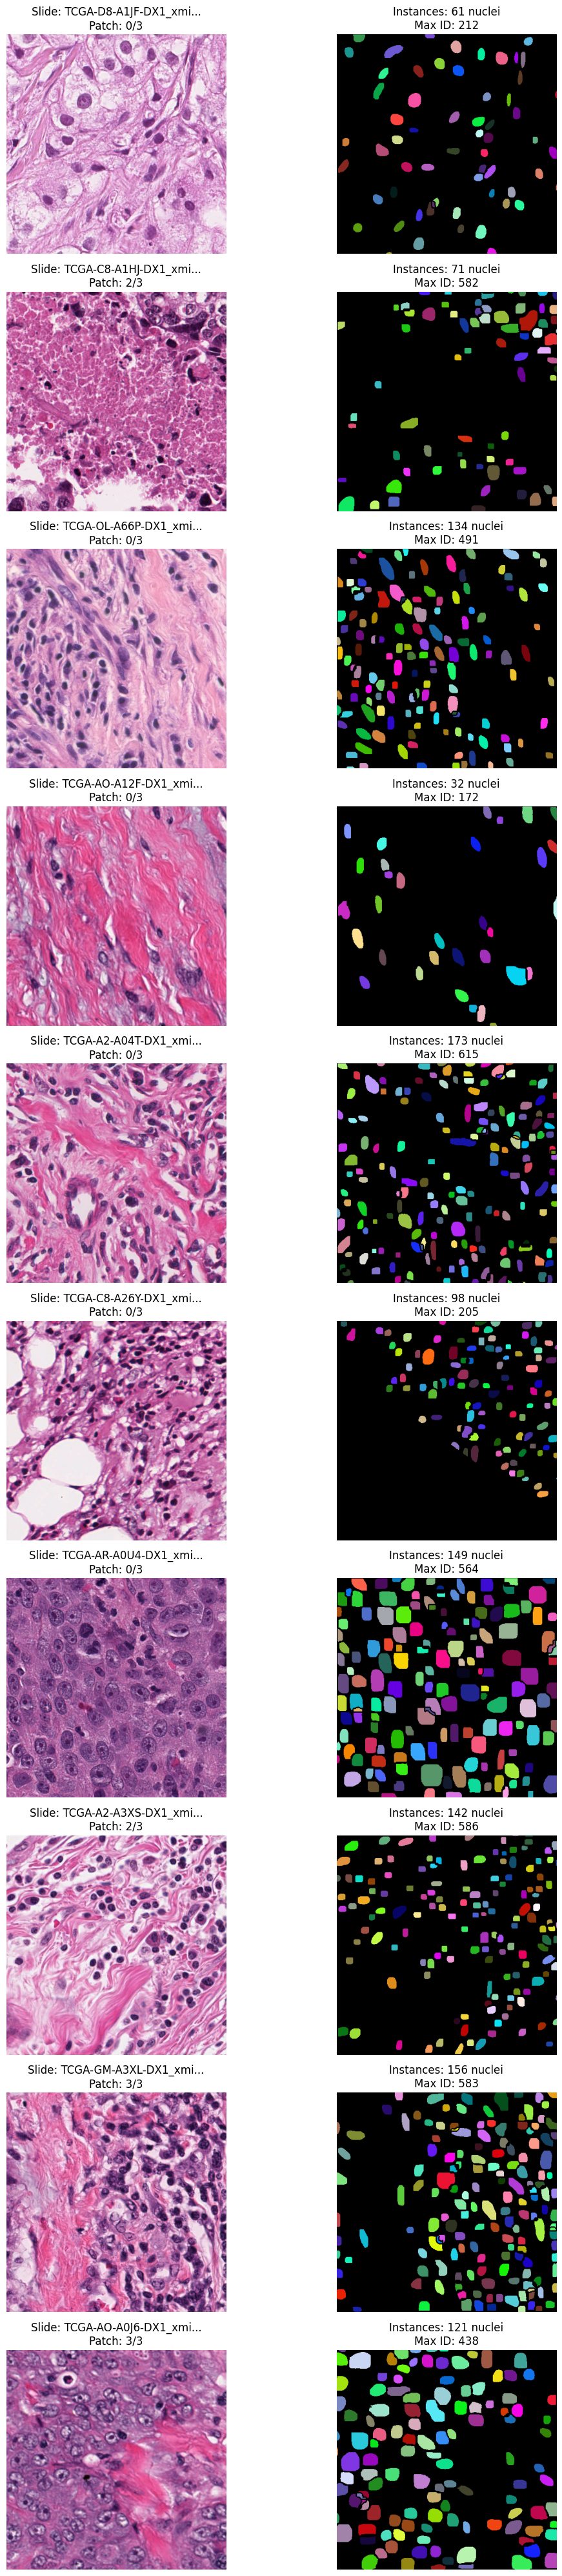

In [9]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# --- CONFIGURATION ---
zarr_base_path = Path("/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/panoptils/zarr_data")

def get_10_random_samples(base_path):
    # Get all subdirectories (each is one image stack)
    all_slides = [d for d in os.listdir(base_path) if os.path.isdir(base_path / d)]
    # Pick 10 random slides (or all if less than 10)
    selected_slides = np.random.choice(all_slides, min(10, len(all_slides)), replace=False)
    return [base_path / s for s in selected_slides]

def colorize_mask(mask):
    """Assigns unique random colors to each instance ID."""
    max_id = int(mask.max())
    if max_id == 0: return np.zeros((*mask.shape, 3))
    # Generate random colors for IDs 1 to max_id, 0 is black
    colors = np.random.rand(max_id + 1, 3)
    colors[0] = [0, 0, 0] 
    return colors[mask]

sample_paths = get_10_random_samples(zarr_base_path)

# --- VISUALIZATION ---
fig, axes = plt.subplots(len(sample_paths), 2, figsize=(12, 4 * len(sample_paths)))

for i, slide_path in enumerate(sample_paths):
    try:
        # 1. Open individual Zarr arrays directly from the slide folder
        z_img = zarr.open(str(slide_path / 'images.zarr'), mode='r')
        z_nuc = zarr.open(str(slide_path / 'nuclei_masks.zarr'), mode='r')
        
        # 2. Pick a random patch index from the stack
        num_patches = z_img.shape[0]
        patch_idx = np.random.randint(0, num_patches)
        
        img_patch = z_img[patch_idx]
        mask_patch = z_nuc[patch_idx]
        
        # 3. Plot RGB Image
        axes[i, 0].imshow(img_patch)
        axes[i, 0].set_title(f"Slide: {slide_path.name[:20]}...\nPatch: {patch_idx}/{num_patches-1}")
        axes[i, 0].axis('off')
        
        # 4. Plot Colorized Instance Mask
        colored_mask = colorize_mask(mask_patch)
        axes[i, 1].imshow(colored_mask)
        num_cells = len(np.unique(mask_patch)) - 1
        axes[i, 1].set_title(f"Instances: {num_cells} nuclei\nMax ID: {mask_patch.max()}")
        axes[i, 1].axis('off')
        
    except Exception as e:
        print(f"Error loading {slide_path.name}: {e}")

plt.tight_layout()
plt.show()